# La Magia de la Transformada Probabilística de Hough (PHT)

En la detección de carriles, necesitamos que el ordenador entienda que una nube de píxeles blancos forman líneas rectas. 

La **Transformada de Hough Estándar (SHT)** hace esto calculando la ecuación polar $\rho = x\cos\theta + y\sin\theta$ para *todos* los píxeles blancos de la imagen. Sin embargo, en el mundo real del procesamiento de vídeo presenta dos problemas críticos:
1. **Es computacionalmente muy costosa.**
2. **Devuelve líneas infinitas:** Nos da un ángulo y una distancia, pero no nos dice dónde empieza o termina el trazo en la pantalla.

Para solucionar esto, Matas, Galambos y Kittler introdujeron en 1999 la **Transformada Probabilística de Hough (PHT)**. 

### ¿Cómo funciona la PHT?
La PHT es una optimización algorítmica. En lugar de procesar toda la imagen, toma una **muestra aleatoria** de píxeles. Una vez que suficientes píxeles aleatorios "votan" por una misma trayectoria, el algoritmo confirma la línea y "camina" por ella para descubrir exactamente en qué coordenada cartesiana $(x_1, y_1)$ empieza y en cuál $(x_2, y_2)$ termina.

Para entender esto visualmente, vamos a generar un "lienzo" sintético: una línea de carretera discontinua rodeada de "ruido" (piedras, reflejos, etc.).

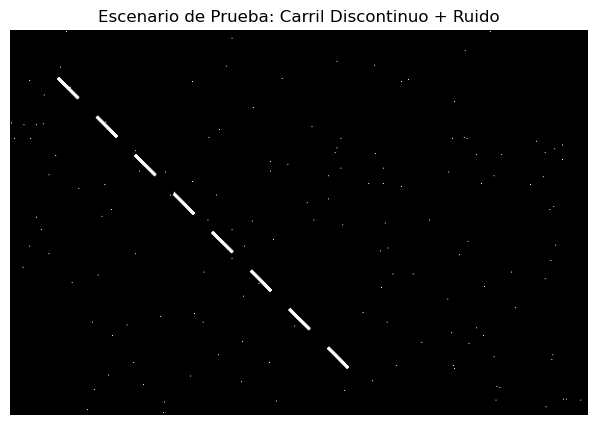

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# 1. Creamos un lienzo negro de 400x600 píxeles
lienzo = np.zeros((400, 600), dtype=np.uint8)

# 2. Dibujamos una línea discontinua (simulando los guiones de un carril)
for i in range(50, 350, 40):
    cv2.line(lienzo, (i, i), (i + 20, i + 20), 255, 2)

# 3. Añadimos ruido aleatorio (simulando reflejos en el asfalto o lluvia)
np.random.seed(42) 
ruido_x = np.random.randint(0, 600, 150)
ruido_y = np.random.randint(0, 400, 150)
lienzo[ruido_y, ruido_x] = 255

# Visualizamos el escenario base
plt.figure(figsize=(8, 5))
plt.imshow(lienzo, cmap='gray')
plt.title("Escenario de Prueba: Carril Discontinuo + Ruido")
plt.axis('off')
plt.show()

### El Simulador: Los 3 Parámetros Mágicos de la PHT

A diferencia de la versión estándar, la función `cv2.HoughLinesP()` en OpenCV nos exige configurar tres hiperparámetros que controlan la "psicología" del algoritmo. Juega con los deslizadores de abajo para entender qué hace cada uno:

1. **`Threshold` (Umbral de Votos):** Número mínimo de píxeles alineados necesarios para considerar que existe una recta.
2. **`Min Line Length` (Longitud Mínima):** La criba de tamaño. Si un segmento detectado mide menos que este valor, se borra. (Perfecto para ignorar el ruido).
3. **`Max Line Gap` (Brecha Máxima):** La capacidad de construir puentes. Distancia máxima permitida en negro entre dos trazos blancos para que el algoritmo decida fusionarlos en una sola línea continua.

In [ ]:
# Función que se actualizará en tiempo real al mover los deslizadores
def simulador_pht(umbral, min_longitud, max_brecha):
    # Ejecutamos la PHT con los parámetros del usuario
    lineas = cv2.HoughLinesP(
        lienzo, 
        rho=1, 
        theta=np.pi/180, 
        threshold=umbral, 
        minLineLength=min_longitud, 
        maxLineGap=max_brecha
    )
    
    # Preparamos el lienzo a color para dibujar
    resultado = cv2.cvtColor(lienzo, cv2.COLOR_GRAY2BGR)
    num_lineas = 0
    
    # Dibujamos los segmentos detectados en colores aleatorios
    if lineas is not None:
        num_lineas = len(lineas)
        for linea in lineas:
            x1, y1, x2, y2 = linea[0]
            # Color aleatorio para distinguir si ha detectado 1 segmento o varios
            color = tuple(np.random.randint(50, 255, 3).tolist())
            cv2.line(resultado, (x1, y1), (x2, y2), color, 4)
            
    # Mostramos el resultado
    plt.figure(figsize=(10, 6))
    plt.imshow(resultado)
    plt.title(f"Segmentos detectados: {num_lineas} \n(Si todo es del mismo color, es una sola línea continua)", fontweight='bold')
    plt.axis('off')
    plt.show()

# Creamos la interfaz de deslizadores
widgets.interact(
    simulador_pht, 
    umbral=widgets.IntSlider(min=1, max=50, step=1, value=10, description='Threshold:'),
    min_longitud=widgets.IntSlider(min=0, max=100, step=1, value=5, description='Min Length:'),
    max_brecha=widgets.IntSlider(min=0, max=100, step=1, value=5, description='Max Gap:')
);

interactive(children=(IntSlider(value=10, description='Threshold:', max=50, min=1), IntSlider(value=5, descrip…

### ¿Por qué los autores del artículo utilizan PHT y no SHT?

El artículo científico de referencia especifica explícitamente el uso de la Transformada Probabilística de Hough para la detección del carril, especialmente de noche (Sección 3.3.1). Esta decisión arquitectónica no es casualidad, sino una necesidad de ingeniería fundamentada en tres pilares:

**1. Rendimiento en Tiempo Real (Eficiencia)**
Un sistema de conducción autónoma procesa entre 30 y 60 fotogramas por segundo. De noche, debido a la alta ganancia de las cámaras, aparece mucho "ruido" de grano en la imagen. La SHT colapsaría la CPU calculando ecuaciones para cada píxel de ruido. La PHT, al usar un muestreo aleatorio (Probabilístico), reduce drásticamente el tiempo de computo.

**2. Resolución de Líneas Discontinuas (`maxLineGap`)**
Como hemos visto en el simulador, las carreteras están llenas de líneas discontinuas. Con la SHT normal, obtendríamos un conjunto de ecuaciones abstractas. Con la PHT, el parámetro de brecha máxima permite al algoritmo saltar sobre el asfalto oscuro y devolvernos un segmento vectorizado unificado, vital para saber hacia dónde va el carril.

**3. Necesidad de Coordenadas Cartesianas (Matemática Aplicada)**
Para identificar el carril real, los autores proponen calcular la distancia al centro de la cámara, la pendiente y el punto medio (Ecuaciones 12 a 17 del *paper*). 
Todas estas fórmulas ($m = \frac{y_2-y_1}{x_2-x_1}$) exigen tener **coordenadas de inicio y fin** $(x_1, y_1, x_2, y_2)$. 
La SHT tradicional devuelve parámetros polares ($\rho$, $\theta$) de líneas infinitas. La PHT es el único método que nos entrega segmentos finitos acotados en el espacio cartesiano de la imagen, permitiéndonos aplicar las fórmulas de los autores de forma directa.